# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the integrated dataset before feature engineering and predictive modeling. This analysis focuses on identifying the distribution of variables, temporal trends, relationships between air quality, fire activity, and meteorological conditions, and potential anomalies within the dataset. The insights obtained during this stage provide the foundation for subsequent feature engineering, hypothesis testing, and machine learning.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

sns.set_theme(style="whitegrid", context="notebook")

master_df = pd.read_csv("master_dataset.csv")
master_df["Date"] = pd.to_datetime(master_df["Date"])

## Visualization Configuration

To ensure consistency and readability throughout the exploratory data analysis, a common visualization style is defined before generating any figures. A unified theme, font, color palette, and layout are applied across all visualizations to maintain a professional and consistent presentation.

In [2]:
sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep"
)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "font.family": "DejaVu Sans"
})

px.defaults.template = "plotly_white"
px.defaults.width = 900
px.defaults.height = 550

COLOR_PALETTE  = {
    "AQI": "#1f77b4",
    "PM2.5": "#4c78a8",
    "Fire": "#ff7f0e",
    "Wind": "#2ca02c",
    "Temperature": "#d62728",
    "Humidity": "#17becf"
}

## 1. Dataset Overview

The analysis begins by examining the overall structure of the integrated master dataset. This includes verifying the number of observations, variables, data types, missing values, and descriptive statistics to ensure that the dataset is complete and suitable for further analysis.

In [3]:
print("Shape:", master_df.shape)

display(master_df.head())

print("\nData Types")
display(master_df.dtypes)

print("\nMissing Values")
display(master_df.isnull().sum())

display(master_df.describe().T.round(2))

Shape: (1851, 15)


,Date,AQI,AQI_Bucket,PM2.5,Fire_Count,Total_FRP,Mean_FRP,Max_FRP,Mean_U10,Mean_V10,Mean_Wind_Speed,Max_Wind_Speed,Avg_Temperature_C,Avg_DewPoint_C,Relative_Humidity
0,2015-01-01,472.0,Severe,313.22,30,129.63,4.321000,11.74,-0.970402,-0.688204,1.757655,2.625952,15.814055,10.725815,71.76
1,2015-01-02,454.0,Severe,186.18,15,84.92,5.661333,16.66,-1.682431,-0.455764,1.946573,3.647534,15.319465,13.485620,88.82
2,2015-01-03,143.0,Moderate,87.18,4,5.93,1.482500,2.07,0.962810,-0.866344,1.492209,2.766795,15.595728,14.065458,90.61
3,2015-01-04,319.0,Very Poor,151.84,15,81.51,5.434000,15.46,1.773298,-1.831503,2.604788,3.700177,13.921083,11.270265,84.05
4,2015-01-05,325.0,Very Poor,146.60,34,110.50,3.250000,8.84,4.105233,-2.425379,4.797141,7.469673,14.195888,9.797250,74.85



Data Types


Date                 datetime64[ns]
AQI                         float64
AQI_Bucket                   object
PM2.5                       float64
Fire_Count                    int64
Total_FRP                   float64
Mean_FRP                    float64
Max_FRP                     float64
Mean_U10                    float64
Mean_V10                    float64
Mean_Wind_Speed             float64
Max_Wind_Speed              float64
Avg_Temperature_C           float64
Avg_DewPoint_C              float64
Relative_Humidity           float64
dtype: object


Missing Values


Date                 0
AQI                  0
AQI_Bucket           0
PM2.5                0
Fire_Count           0
Total_FRP            0
Mean_FRP             0
Max_FRP              0
Mean_U10             0
Mean_V10             0
Mean_Wind_Speed      0
Max_Wind_Speed       0
Avg_Temperature_C    0
Avg_DewPoint_C       0
Relative_Humidity    0
dtype: int64

,count,mean,min,25%,50%,75%,max,std
Date,1851,2017-10-01 17:56:41.620745472,2015-01-01 00:00:00,2016-05-06 12:00:00,2017-10-10 00:00:00,2019-02-17 12:00:00,2020-07-01 00:00:00,NaN
AQI,1851.0,267.704484,30.0,172.5,268.0,352.0,716.0,117.929309
PM2.5,1851.0,122.505132,11.81,61.54,101.02,161.17,685.36,83.353626
Fire_Count,1851.0,303.855754,1.0,11.0,40.0,133.0,8659.0,758.97854
Total_FRP,1851.0,1963.02107,0.44,37.06,157.77,672.63,61479.85,5348.478384
Mean_FRP,1851.0,4.360747,0.44,3.093439,4.03,5.485909,23.553592,2.151164
Max_FRP,1851.0,25.66698,0.44,6.845,13.58,33.15,211.37,29.940094
Mean_U10,1851.0,0.342097,-5.882892,-0.894279,0.514215,1.673209,5.482586,1.751806
Mean_V10,1851.0,-0.465155,-3.323114,-1.274002,-0.565384,0.271519,3.811652,1.056102
Mean_Wind_Speed,1851.0,2.357453,0.889525,1.781332,2.219227,2.759986,6.747771,0.767559


### Findings

The integrated master dataset consists of **1,851 daily observations** and **15 variables** representing air quality, fire activity, wind characteristics, and meteorological conditions. No missing values remain after preprocessing, indicating that the dataset is complete and ready for analysis. The descriptive statistics reveal substantial variability across AQI and fire-related variables, suggesting that the dataset contains sufficient variation for investigating the relationship between external fire activity, weather conditions, and Delhi's air quality.

# 2. Air Quality Analysis

Air quality is the primary focus of this study, with the Air Quality Index (AQI) serving as the response variable for both the analytical and predictive components of the project. This section examines the distribution and characteristics of AQI and PM2.5 to understand the overall air pollution conditions in Delhi during the study period.

## 2.1 Distribution of Air Quality Index (AQI)

The distribution of AQI is analyzed to understand its central tendency, variability, and overall spread during the study period. Examining the distribution also helps identify skewness and the occurrence of extreme pollution events.

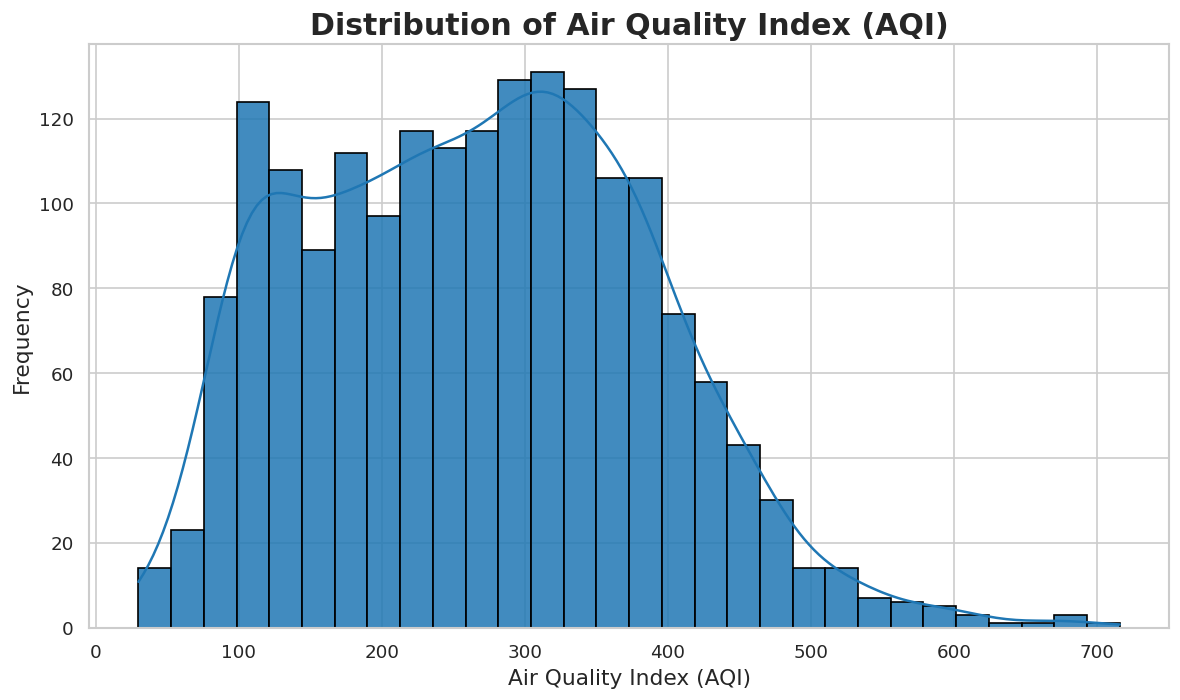

In [4]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=master_df,
    x="AQI",
    bins=30,
    kde=True,
    color=COLOR_PALETTE["AQI"],
    edgecolor="black",
    alpha=0.85
)

plt.title("Distribution of Air Quality Index (AQI)")
plt.xlabel("Air Quality Index (AQI)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 2.2 Distribution of AQI Categories

The AQI categories are examined to understand the frequency of different pollution levels experienced during the study period. This analysis provides an overview of how often Delhi experienced good, moderate, poor, and severe air quality conditions according to the AQI classification.

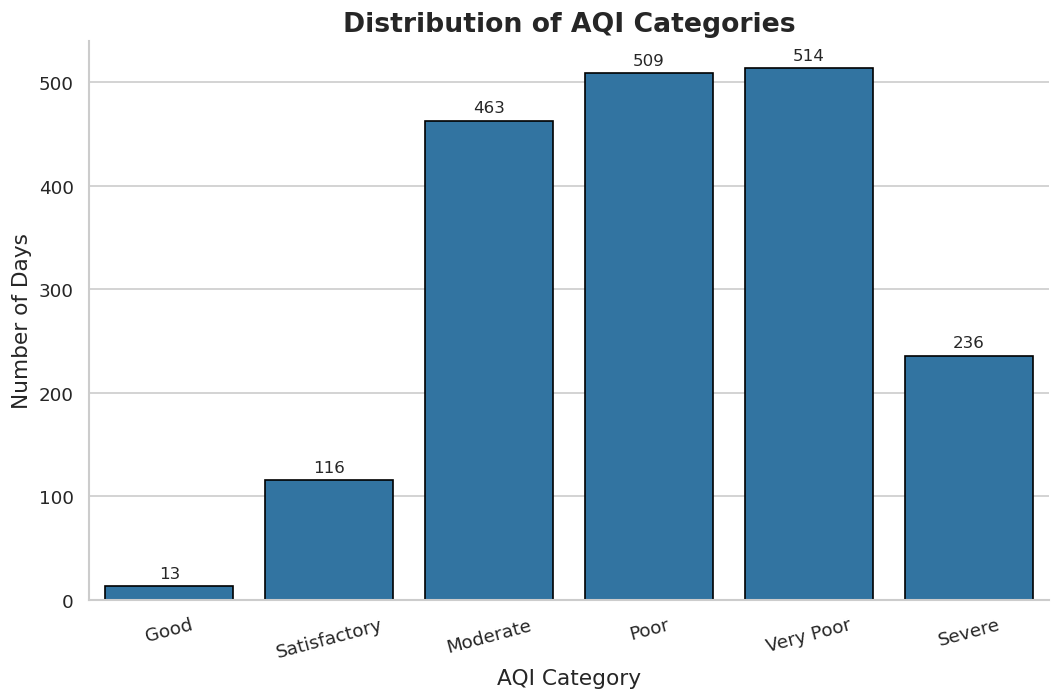

In [8]:
plt.figure(figsize=(9, 6))

order = [
    "Good",
    "Satisfactory",
    "Moderate",
    "Poor",
    "Very Poor",
    "Severe"
]

ax = sns.countplot(
    data=master_df,
    x="AQI_Bucket",
    order=order,
    color=COLOR_PALETTE["AQI"],
    edgecolor="black"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3,
        fontsize=10
    )

plt.title("Distribution of AQI Categories", fontsize=16, weight="bold")
plt.xlabel("AQI Category")
plt.ylabel("Number of Days")
plt.xticks(rotation=15)

sns.despine()

plt.tight_layout()
plt.show()

### Findings

The AQI category distribution indicates that Delhi experienced **predominantly Poor, Very Poor, and Moderate** air quality during the study period. Days classified as **Good** or **Satisfactory** were relatively infrequent, whereas **Poor** and **Very Poor** categories accounted for the largest proportion of observations.

The presence of a considerable number of **Severe** air quality days further highlights the occurrence of extreme pollution episodes, emphasizing the need to investigate the contribution of external fire activity and meteorological conditions to deteriorating air quality.

## 2.3 Distribution of PM2.5

PM2.5 is one of the most harmful air pollutants due to its ability to penetrate deep into the respiratory system. Examining its distribution provides insights into the concentration levels observed during the study period and complements the AQI analysis.

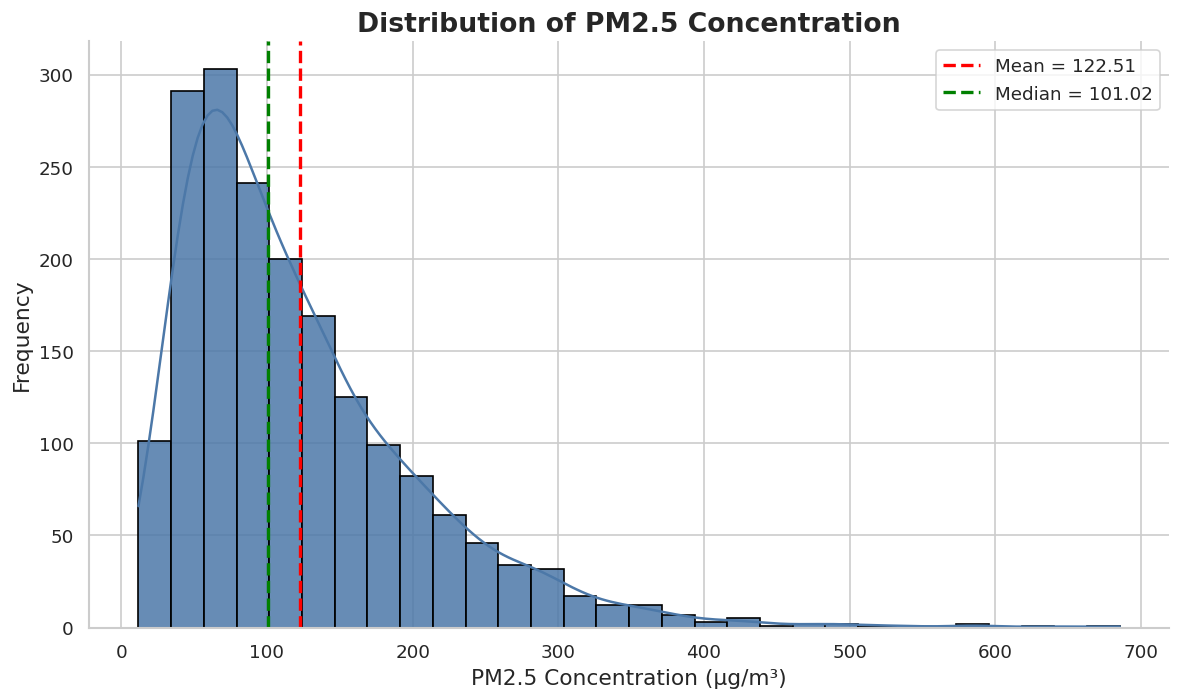

In [9]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=master_df,
    x="PM2.5",
    bins=30,
    kde=True,
    color=COLOR_PALETTE["PM2.5"],
    edgecolor="black",
    alpha=0.85
)

mean_pm = master_df["PM2.5"].mean()
median_pm = master_df["PM2.5"].median()

plt.axvline(
    mean_pm,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_pm:.2f}"
)

plt.axvline(
    median_pm,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_pm:.2f}"
)

plt.title("Distribution of PM2.5 Concentration", fontsize=16, weight="bold")
plt.xlabel("PM2.5 Concentration (µg/m³)")
plt.ylabel("Frequency")

plt.legend()

sns.despine()

plt.tight_layout()
plt.show()

### Findings

The PM2.5 concentration exhibits a **positively skewed distribution**, with most observations occurring at relatively lower concentration levels and a long right tail representing high pollution episodes.

The mean PM2.5 concentration (**122.51 µg/m³**) is greater than the median (**101.02 µg/m³**), confirming the presence of right-skewness caused by occasional extreme pollution events. The wide spread of PM2.5 concentrations indicates substantial variability in particulate matter levels throughout the study period.

### Section Summary

The air quality analysis indicates that Delhi experienced predominantly **moderate to severe** air pollution during the study period. The AQI distribution shows frequent high pollution levels with occasional extreme pollution episodes, while the AQI category distribution reveals that **Poor** and **Very Poor** air quality conditions occurred most frequently. Similarly, the PM2.5 distribution demonstrates considerable variability and a positively skewed pattern, reflecting intermittent periods of exceptionally high particulate matter concentrations. These observations establish the baseline characteristics of Delhi's air quality and motivate further investigation into the influence of external fire activity and meteorological conditions.

# 3. Fire Activity Analysis

Fire activity is one of the primary explanatory variables considered in this study. This section examines the characteristics of external fire activity using the daily fire count and Fire Radiative Power (FRP) variables. Understanding the frequency and intensity of fire events provides the foundation for investigating their potential influence on Delhi's air quality.

## 3.1 Distribution of Daily Fire Count

The daily fire count represents the number of satellite-detected fire events within the selected study region for each day. Analyzing its distribution helps identify the frequency of fire occurrences and determine whether fire activity is concentrated around specific intensity levels or dominated by extreme events.

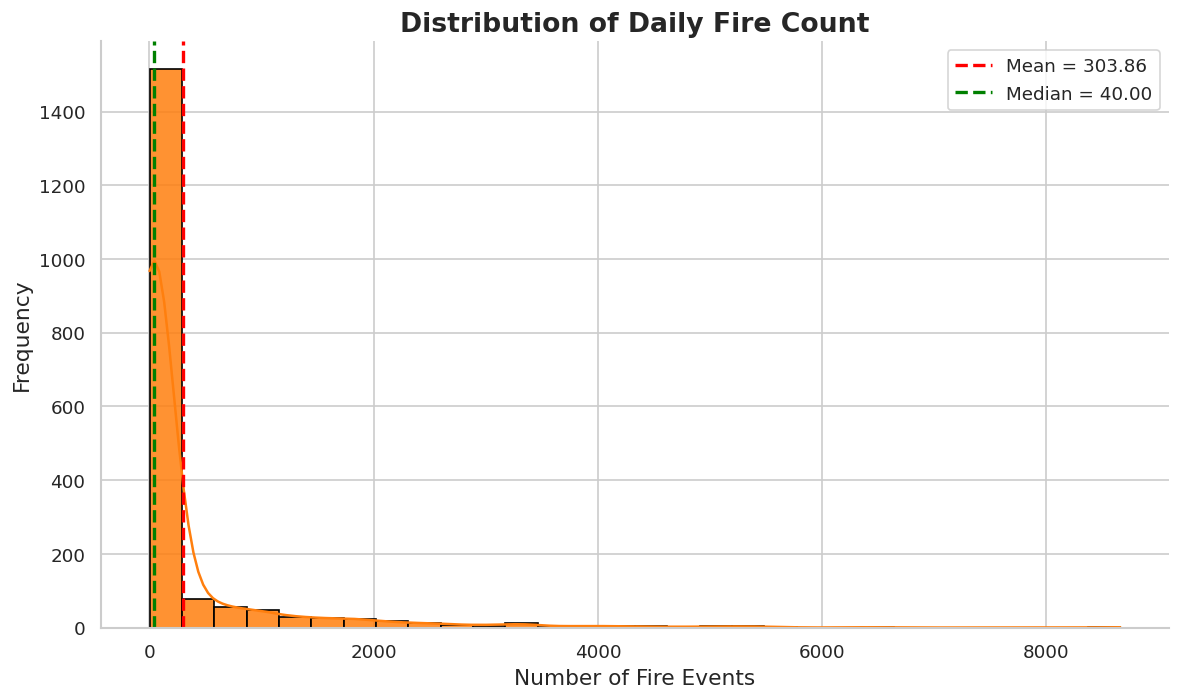

In [10]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=master_df,
    x="Fire_Count",
    bins=30,
    kde=True,
    color=COLOR_PALETTE["Fire"],
    edgecolor="black",
    alpha=0.85
)

mean_fire = master_df["Fire_Count"].mean()
median_fire = master_df["Fire_Count"].median()

plt.axvline(
    mean_fire,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_fire:.2f}"
)

plt.axvline(
    median_fire,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_fire:.2f}"
)

plt.title("Distribution of Daily Fire Count", fontsize=16, weight="bold")
plt.xlabel("Number of Fire Events")
plt.ylabel("Frequency")

plt.legend()

sns.despine()

plt.tight_layout()
plt.show()

### Findings

The daily fire count exhibits a **highly positively skewed distribution**, with most days recording relatively few fire events and a small number of days experiencing exceptionally high fire activity.

The substantial difference between the **mean (303.86)** and the **median (40.00)** indicates that the distribution is strongly influenced by extreme fire events. These occasional spikes suggest the presence of seasonal fire episodes, which may have a significant impact on regional air quality and warrant further investigation in the subsequent temporal and relationship analyses.

## 3.2 Distribution of Total Fire Radiative Power (Total_FRP)

Total Fire Radiative Power (FRP) represents the cumulative intensity of all detected fire events on a given day. Analyzing its distribution provides insights into the daily magnitude of fire activity and helps determine whether fire intensity is dominated by frequent low-intensity events or occasional extreme fire episodes.

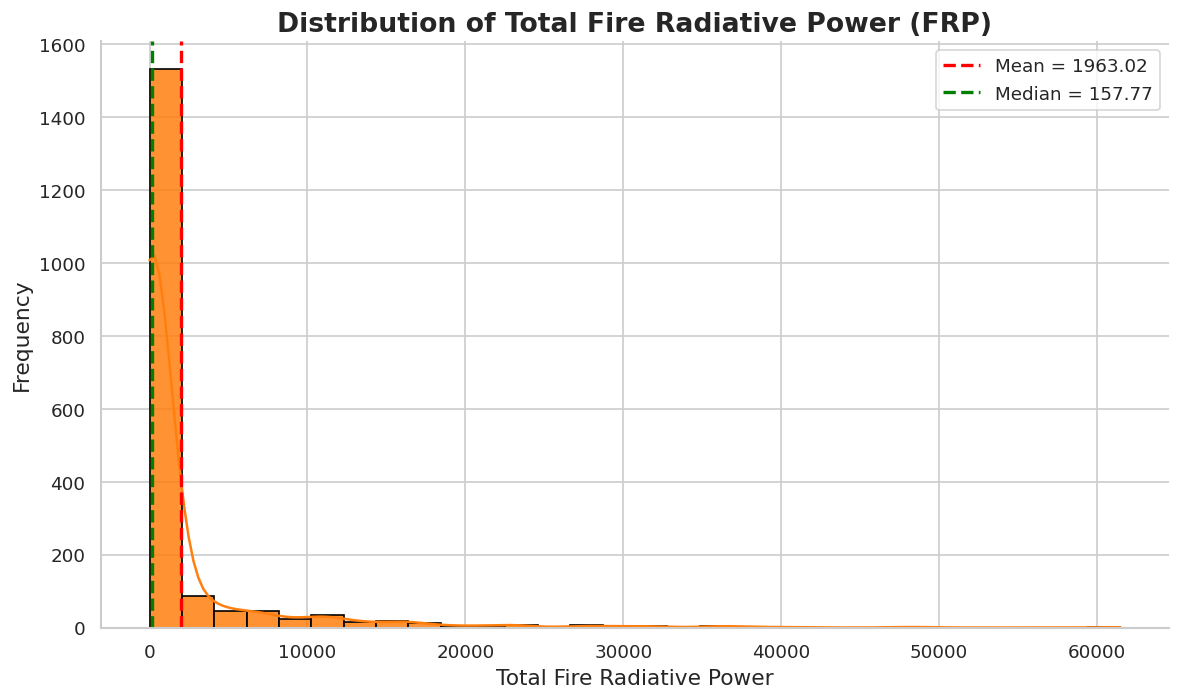

In [11]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=master_df,
    x="Total_FRP",
    bins=30,
    kde=True,
    color=COLOR_PALETTE["Fire"],
    edgecolor="black",
    alpha=0.85
)

mean_frp = master_df["Total_FRP"].mean()
median_frp = master_df["Total_FRP"].median()

plt.axvline(
    mean_frp,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_frp:.2f}"
)

plt.axvline(
    median_frp,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_frp:.2f}"
)

plt.title("Distribution of Total Fire Radiative Power (FRP)", fontsize=16, weight="bold")
plt.xlabel("Total Fire Radiative Power")
plt.ylabel("Frequency")

plt.legend()

sns.despine()

plt.tight_layout()
plt.show()

### Findings

The distribution of **Total Fire Radiative Power (Total_FRP)** is highly positively skewed, with most days exhibiting relatively low cumulative fire intensity and a small number of days experiencing exceptionally high fire activity.

The large difference between the **mean (1963.02)** and the **median (157.77)** indicates that the distribution is dominated by a limited number of extreme fire events. These high-intensity fire episodes are likely associated with seasonal biomass burning and may contribute disproportionately to regional air pollution.

### Section Summary

The fire activity analysis indicates that both the daily fire count and total fire radiative power exhibit highly positively skewed distributions. Most days experienced relatively low to moderate fire activity, while a small number of days were characterized by exceptionally large fire events and high cumulative fire intensity.

The substantial differences between the mean and median values of both variables suggest that seasonal biomass burning events dominate the upper range of the distributions. These extreme fire episodes provide a strong basis for investigating whether periods of intensified fire activity are associated with deteriorating air quality in Delhi.